In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize


In [3]:
plt.rcParams["figure.dpi"] = 100
plt.rcParams["text.usetex"] = True
plt.rcParams["font.size"] = 12


# matplotlib.rcParams['mathtext.fontset'] = 'stix'
# matplotlib.rcParams['font.family'] = 'Computer Modern'


plt.rcParams['font.family'] = 'serif' # or 'sans-serif' or 'monospace'
plt.rcParams['font.serif'] = 'cmr10'
plt.rcParams['font.sans-serif'] = 'cmss10'
plt.rcParams['font.monospace'] = 'cmtt10'
plt.rcParams["axes.formatter.use_mathtext"] = True # to fix the minus signs
%config InlineBackend.figure_format = 'retina'
#plt.rcParams['axes.grid'] = True

0.14747191011236044


/var/folders/y_/zv0y5yrn157c9vh3d56h15qh0000gp/T/ipykernel_2923/1938935399.py:16: RuntimeWarning: invalid value encountered in sqrt
  m_err = np.sqrt(pcov[0])
/var/folders/y_/zv0y5yrn157c9vh3d56h15qh0000gp/T/ipykernel_2923/1938935399.py:17: RuntimeWarning: invalid value encountered in sqrt
  b_err = np.sqrt(pcov[1])


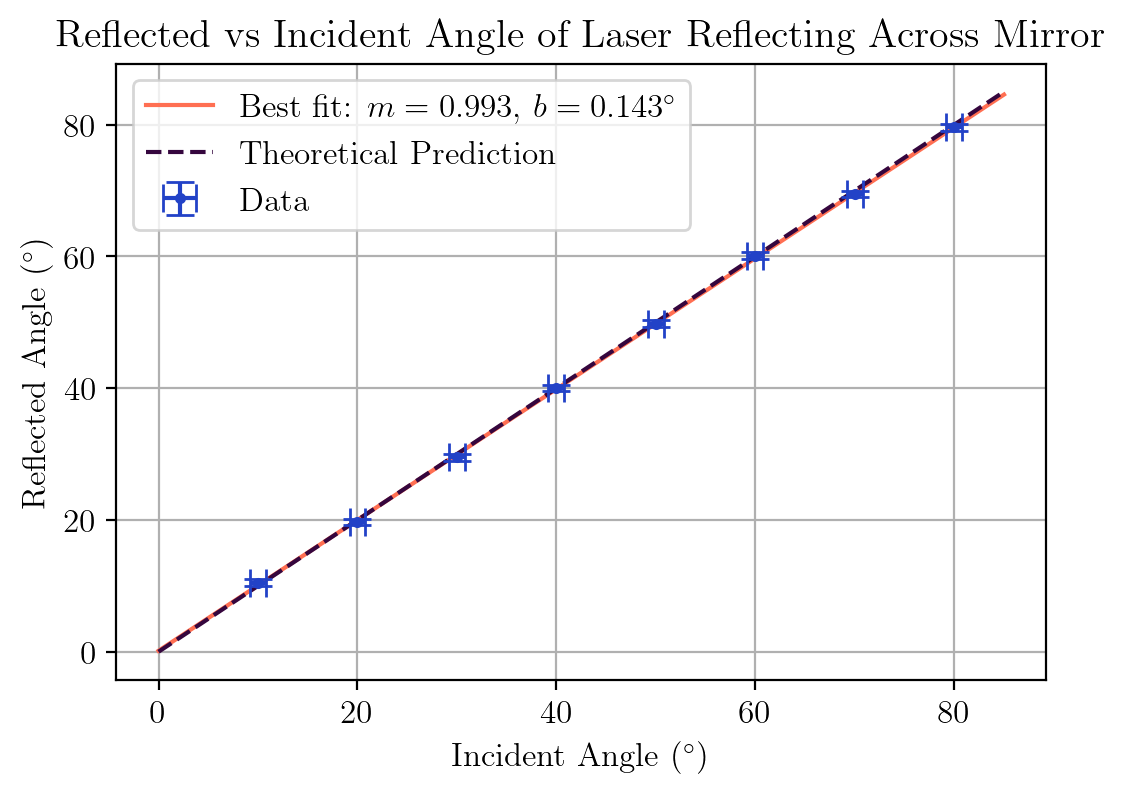

In [7]:
incident = np.array([10, 20, 30, 40, 50, 60, 70, 80])
reflected = np.array([10.5, 19.7, 29.5, 40.0, 49.8, 60.1, 69.5, 79.6])
refl_errors = 0.8 * np.ones(8)
inc_errors = 0.5 * np.ones(8)

equiv_errors = np.sqrt(refl_errors**2 + inc_errors**2)

def line(x, m, b):
    return m*x + b


popt, pcov = scipy.optimize.curve_fit(line, incident, reflected, sigma = equiv_errors)

m = popt[0]
b = popt[1]
m_err = np.sqrt(pcov[0])
b_err = np.sqrt(pcov[1])

chi_squared = np.sum((reflected - incident)**2 / equiv_errors**2)
reduced_chi_squared = chi_squared / (len(incident))

print(reduced_chi_squared)

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(incident, reflected, inc_errors, refl_errors, fmt = 'o', markersize = 3, capsize = 5, color = 'xkcd:blue blue', zorder=10, label="Data")

x_vals = np.linspace(0, 85, 100)
ax.plot(x_vals, line(x_vals, m, b), color = "xkcd:orange pink", label = rf"Best fit: $m = {m:0.3f}$, $b = {b:0.3f}^\circ$")
ax.plot(x_vals, x_vals, color = "xkcd:dark purple", label = rf"Theoretical Prediction", linestyle='dashed')

ax.set_title(r"Reflected vs Incident Angle of Laser Reflecting Across Mirror")
ax.set_xlabel(r"Incident Angle $(^\circ)$")
ax.set_ylabel(r"Reflected Angle $(^\circ)$")
ax.grid()
ax.legend()

fig.savefig("reflection_angle_plot.png", dpi=400)




